# FF49 Conditional Diffusion Pipeline

This notebook calls the refactored `.py` modules from `portfolio_diffusion/`. Put `49_Industry_Portfolios.csv` in `data/` before running.

In [1]:
from pathlib import Path
import sys

# Works whether the notebook is run from repo root or notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from portfolio_diffusion import (
    DDPMConfig,
    ConditionalRecurrentDDPM,
    TrainCfg,
    seed_everything,
    fit,
    build_dataloader,
    load_ff49_monthly_value_weighted_drop_columns,
    split_train_valid_test,
    standardize_train_valid,
    run_generative_markowitz_backtest,
    make_backtest_dataframe,
    performance_stats,
    compute_rebalance_turnover,
    build_weight_dataframe,
    build_average_weights_dataframe,
    save_scenario_dataset_for_rl,
)
from portfolio_diffusion.plotting import plot_wealth, plot_average_weights, plot_turnover
from portfolio_diffusion import (
    generated_scenario_diagnostics,
    run_portfolio_variants_from_scenarios,
)
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load FF49 monthly returns

In [2]:
csv_path = PROJECT_ROOT / "data" / "49_Industry_Portfolios.csv"

monthly_returns_df, dropped_columns, missing_count = load_ff49_monthly_value_weighted_drop_columns(
    csv_path,
    start_date="1929-01-01",
)

industry_names = list(monthly_returns_df.columns)
num_assets = len(industry_names)

print("Monthly data shape:", monthly_returns_df.shape)
print("Monthly date range:", monthly_returns_df.index.min(), "to", monthly_returns_df.index.max())
print("Number of industries kept:", num_assets)
print("Dropped industries:", dropped_columns)

Monthly data shape: (1167, 41)
Monthly date range: 1929-01-01 00:00:00 to 2026-03-01 00:00:00
Number of industries kept: 41
Dropped industries: ['Soda', 'Hlth', 'Rubbr', 'FabPr', 'Guns', 'Gold', 'Softw', 'Paper']


## 2. Split and standardize

In [3]:
train_df, valid_target_df, test_target_df = split_train_valid_test(
    monthly_returns_df,
    train_end="2010-12-31",
    valid_start="2011-01-01",
    valid_end="2015-12-31",
    test_start="2016-01-01",
)

print("Train shape:", train_df.shape, train_df.index.min(), "to", train_df.index.max())
print("Validation shape:", valid_target_df.shape, valid_target_df.index.min(), "to", valid_target_df.index.max())
print("Test shape:", test_target_df.shape, test_target_df.index.min(), "to", test_target_df.index.max())

Train shape: (984, 41) 1929-01-01 00:00:00 to 2010-12-01 00:00:00
Validation shape: (60, 41) 2011-01-01 00:00:00 to 2015-12-01 00:00:00
Test shape: (123, 41) 2016-01-01 00:00:00 to 2026-03-01 00:00:00


## 3. Configure model

In [4]:
seed_everything(42)

cfg = DDPMConfig(
    input_dim=num_assets,
    context_length=36,
    prediction_length=1,
    rnn_type="LSTM",
    rnn_hidden_dim=128,
    rnn_layers=2,
    rnn_dropout=0.05,
    unet_base_channels=64,
    unet_depth=3,
    time_embed_dim=128,
    diffusion_steps=500,
    beta_start=1e-4,
    beta_end=2e-2,
    batch_size=16,
    lr=2e-4,
    epochs=100,
    grad_clip=1.0,
    weight_decay=1e-4,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

device = torch.device(cfg.device)
print("Device:", device)
print("Input dim:", cfg.input_dim)
print("Context length:", cfg.context_length)

Device: cuda
Input dim: 41
Context length: 36


In [5]:
train_returns, valid_returns, mean, std, valid_with_context_df = standardize_train_valid(
    train_df=train_df,
    valid_target_df=valid_target_df,
    context_length=cfg.context_length,
)

print("Train raw shape:", train_df.values.shape)
print("Valid raw with context shape:", valid_with_context_df.values.shape)
print("Train standardized mean avg:", train_returns.mean(axis=0).mean())
print("Train standardized std avg:", train_returns.std(axis=0).mean())

Train raw shape: (984, 41)
Valid raw with context shape: (96, 41)
Train standardized mean avg: 5.0822924e-10
Train standardized std avg: 0.9999998


## 4. Dataloaders

The dataset returns repo-style sequence-to-sequence targets with shape `[batch, context_length, prediction_length, num_assets]`.

In [6]:
train_dataset, train_loader = build_dataloader(
    series=train_returns,
    cfg=cfg,
    shuffle=True,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=True,
)

valid_dataset, valid_loader = build_dataloader(
    series=valid_returns,
    cfg=cfg,
    shuffle=False,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=False,
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

batch = next(iter(train_loader))
print("context shape:", batch["context"].shape)
print("target shape:", batch["target"].shape)

Train samples: 948
Validation samples: 60
context shape: torch.Size([16, 36, 41])
target shape: torch.Size([16, 36, 1, 41])


## 5. Train diffusion model

In [8]:
model = ConditionalRecurrentDDPM(cfg).to(device)

train_cfg = TrainCfg(
    optim_name="AdamW",
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
    scheduler="cosine",
    num_epochs=cfg.epochs,
    use_ema=True,
    ema_decay=0.999,
    max_grad_norm=cfg.grad_clip,
    amp=torch.cuda.is_available(),
    patience=5,
    seed=42,
    save_path=str(OUTPUT_DIR / "best_ff49_monthly_dropcols_pre2011.pt"),
    force_lazy_modules=True,
)

best_model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    device=device,
    cfg=train_cfg,
)

[001/100] train=0.341322 val=0.647515 lr=2.00e-04 t=0.1m


[002/100] train=0.278128 val=0.519324 lr=2.00e-04 t=0.1m


[003/100] train=0.273039 val=0.469814 lr=2.00e-04 t=0.2m


[004/100] train=0.270657 val=0.442439 lr=1.99e-04 t=0.2m


[005/100] train=0.264693 val=0.401636 lr=1.99e-04 t=0.3m


...

[025/100] train=0.175177 val=0.260351 lr=1.72e-04 t=1.3m


[026/100] train=0.166552 val=0.265336 lr=1.70e-04 t=1.4m


[027/100] train=0.159081 val=0.256907 lr=1.68e-04 t=1.4m


[028/100] train=0.151082 val=0.256399 lr=1.66e-04 t=1.5m


[029/100] train=0.141535 val=0.268522 lr=1.63e-04 t=1.5m
Early stopping


## 6. Rolling scenario generation and Markowitz backtest

In [10]:
backtest_results = run_generative_markowitz_backtest(
    model=best_model,
    monthly_returns_df=monthly_returns_df,
    test_target_df=test_target_df,
    mean=mean,
    std=std,
    cfg=cfg,
    num_scenarios=1000,
    risk_aversion=5.0,
    eta=1.0,
    cov_shrinkage=0.05,
    weight_cap=None,
)

bt_df = make_backtest_dataframe(backtest_results)
bt_df.head()

/home/aghapour/.conda/envs/ldm/lib/python3.8/site-packages/torch/nn/modules/rnn.py:917: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:1424.)
  result = _VF.lstm(input, hx, self._flat_weights, self.bias, self.num_layers,


,Generative_Markowitz_Return,Equal_Weight_Return,Generative_Markowitz_Wealth,Equal_Weight_Wealth
2016-01-01,-0.059031,-0.061449,0.940969,0.938551
2016-02-01,0.015436,0.017446,0.955494,0.954926
2016-03-01,0.075754,0.079585,1.027876,1.030924
2016-04-01,0.045524,0.019932,1.074670,1.051472
2016-05-01,0.010214,0.009800,1.085646,1.061776


In [11]:
diag_by_date, diag_by_asset = generated_scenario_diagnostics(
    backtest_results=backtest_results,
    monthly_returns_df=monthly_returns_df[industry_names],
    lookback=120,
    cov_shrinkage=0.0,
    asset_names=industry_names,
)

display(diag_by_date.describe().T)
display(
    diag_by_asset.sort_values(
        "mean_mae_vs_realized",
        ascending=False,
    ).head(15)
)

diag_by_date.to_csv(OUTPUT_DIR / "ff49_generated_scenario_diagnostics_by_date.csv")
diag_by_asset.to_csv(OUTPUT_DIR / "ff49_generated_scenario_diagnostics_by_asset.csv", index=False)

,count,mean,std,min,25%,50%,75%,max
mean_mae_vs_realized,123.0,0.060578,0.033123,0.023156,0.039946,0.050023,0.072354,0.228702
mean_mae_vs_historical,123.0,0.039179,0.003000,0.032147,0.036816,0.038980,0.041248,0.047996
vol_mae_vs_realized_abs,123.0,0.043507,0.009873,0.024640,0.037295,0.043107,0.049303,0.108620
vol_mae_vs_historical,123.0,0.019511,0.003242,0.013971,0.016929,0.019194,0.021894,0.029446
cov_fro_error_vs_historical,123.0,0.102765,0.020852,0.058477,0.088125,0.099243,0.115327,0.164129
cov_relative_fro_error_vs_historical,123.0,0.965803,0.306030,0.449631,0.709662,0.922750,1.208239,1.730041
historical_obs_used,123.0,120.000000,0.000000,120.000000,120.000000,120.000000,120.000000,120.000000


,asset,mean_mae_vs_realized,mean_mae_vs_historical,gen_vol_avg,realized_abs_return_avg,hist_vol_avg,vol_mae_vs_realized_abs,vol_mae_vs_historical
22,Coal,0.107873,0.078397,0.110009,0.096667,0.133676,0.063044,0.023710
18,Autos,0.097655,0.038049,0.083838,0.089594,0.096063,0.062964,0.016866
15,Steel,0.084737,0.053183,0.089721,0.078794,0.088839,0.050247,0.007691
12,Txtls,0.084376,0.042081,0.081246,0.073594,0.089661,0.046103,0.013014
38,RlEst,0.077508,0.052097,0.114422,0.062692,0.081159,0.063566,0.033326
4,Toys,0.076099,0.050001,0.098476,0.064354,0.071059,0.051547,0.027417
21,Mines,0.073329,0.041900,0.074134,0.068381,0.088338,0.043586,0.014248
14,Cnstr,0.071478,0.052356,0.099971,0.062316,0.070841,0.054127,0.029130
5,Fun,0.071396,0.047781,0.099945,0.062160,0.079928,0.053539,0.020262
17,ElcEq,0.069646,0.039927,0.079638,0.061854,0.066650,0.044409,0.012988


In [12]:
variant_results = run_portfolio_variants_from_scenarios(
    backtest_results=backtest_results,
    monthly_returns_df=monthly_returns_df[industry_names],
    risk_aversion=20.0,
    cov_shrinkage=0.50,
    historical_lookback=120,
    mean_shrinkage=0.75,
    weight_cap=0.10,
    risk_tilt_strength=0.50,
)

display(variant_results["stats"])

variant_results["stats"].to_csv(OUTPUT_DIR / "ff49_robust_portfolio_variant_stats.csv")
variant_results["returns"].to_csv(OUTPUT_DIR / "ff49_robust_portfolio_variant_returns.csv")

,Months,Final Wealth,Annual Return,Annual Volatility,Sharpe,Sortino,Max Drawdown,Monthly Mean,Monthly Std,Best Month,Worst Month,Average Turnover,Average Max Weight,Average Effective N
Strategy,,,,,,,,,,,,,,
equal_weight,123,3.450263,0.128427,0.173096,0.741940,1.021326,-0.272455,0.011378,0.049968,0.154612,-0.183241,0.041562,0.024390,41.000000
generated_markowitz_capped,123,3.757073,0.137844,0.176904,0.779203,1.078227,-0.294097,0.012134,0.051068,0.160225,-0.184516,0.687406,0.099913,13.894753
generated_markowitz_mean_shrunk,123,2.640624,0.099366,0.139467,0.712465,1.059827,-0.210585,0.008740,0.040261,0.107386,-0.102641,0.327049,0.099999,13.820644
equal_weight_diffusion_risk_tilt,123,3.381989,0.126229,0.170222,0.741553,1.024776,-0.267083,0.011172,0.049139,0.151713,-0.177732,0.046329,0.031007,40.618183


## 7. Performance statistics

In [13]:
gm_stats = performance_stats(
    bt_df["Generative_Markowitz_Return"].values,
    wealth=bt_df["Generative_Markowitz_Wealth"].values,
)
ew_stats = performance_stats(
    bt_df["Equal_Weight_Return"].values,
    wealth=bt_df["Equal_Weight_Wealth"].values,
)

stats_df = pd.DataFrame({"Generative Markowitz": gm_stats, "1/N Equal Weight": ew_stats})
stats_df

,Generative Markowitz,1/N Equal Weight
Months,123.000000,123.000000
Final Wealth,4.934968,3.450263
Annual Return,0.168524,0.128427
Annual Volatility,0.257655,0.173096
Sharpe,0.654067,0.741940
Sortino,0.824715,1.021326
Max Drawdown,-0.560090,-0.272455
Monthly Mean,0.015999,0.011378
Monthly Std,0.074379,0.049968
Best Month,0.184276,0.154612


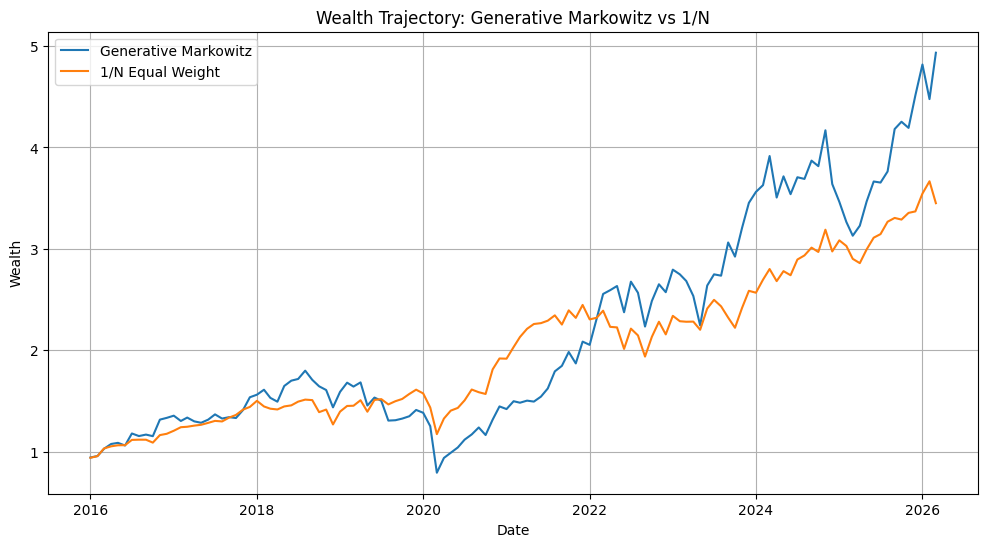

In [14]:
fig, ax = plot_wealth(bt_df)
plt.show()

## 8. Weights and turnover

In [15]:
weights_df = build_weight_dataframe(backtest_results, industry_names)
avg_weights_df = build_average_weights_dataframe(weights_df)
avg_weights_df.head(20)

,Industry,Average_GM_Weight,Equal_Weight
22,Coal,0.328075,0.02439
29,Chips,0.082193,0.02439
14,Cnstr,0.080732,0.02439
19,Aero,0.062267,0.02439
15,Steel,0.056953,0.02439
5,Fun,0.048047,0.02439
26,PerSv,0.036594,0.02439
38,RlEst,0.029220,0.02439
12,Txtls,0.026409,0.02439
18,Autos,0.025808,0.02439


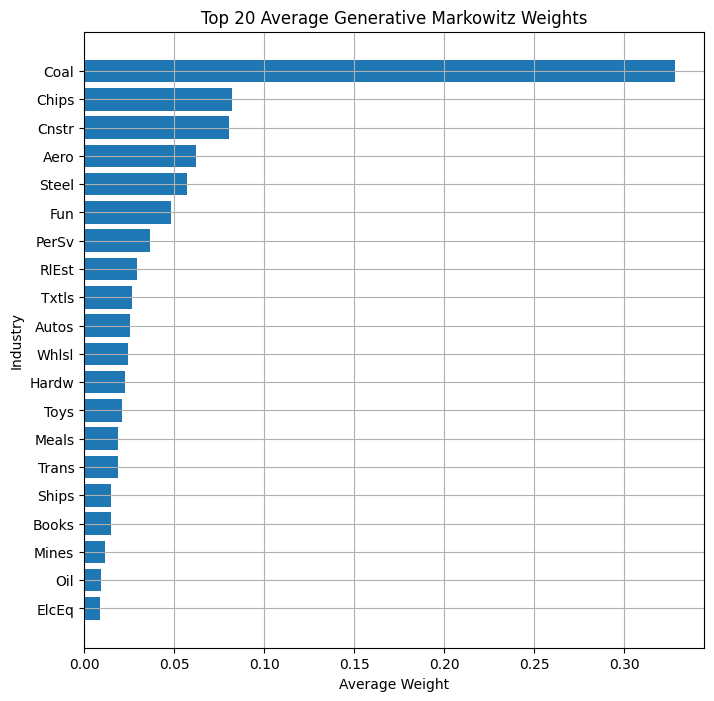

In [16]:
fig, ax = plot_average_weights(avg_weights_df, top_n=20)
plt.show()

Average monthly turnover: 0.95045128929934
Median monthly turnover: 0.8853452072201129
Max monthly turnover: 1.9999998573989386


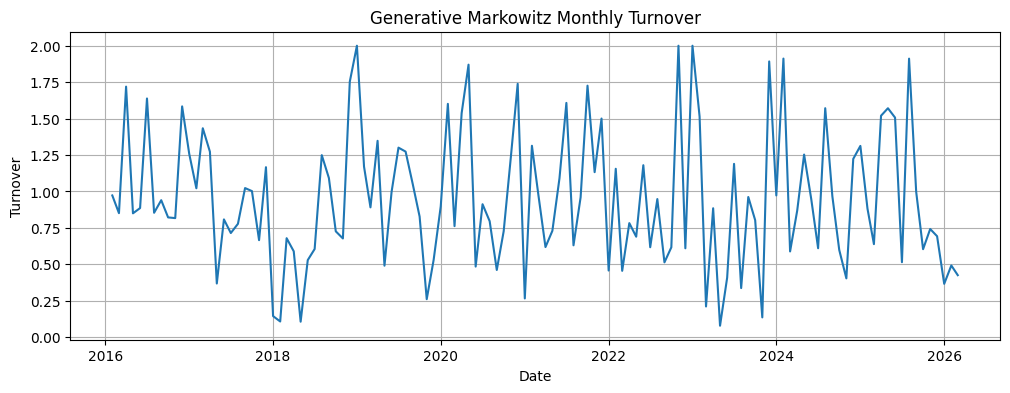

In [17]:
# Simple target-to-target turnover, matching the original notebook.
turnover = np.abs(backtest_results["gm_weights"][1:] - backtest_results["gm_weights"][:-1]).sum(axis=1)
turnover_df = pd.DataFrame({"Turnover": turnover}, index=backtest_results["dates"][1:])

print("Average monthly turnover:", turnover.mean())
print("Median monthly turnover:", np.median(turnover))
print("Max monthly turnover:", turnover.max())

fig, ax = plot_turnover(turnover_df)
plt.show()

In [18]:
# More realistic drift-adjusted turnover for both strategies.
R_test = backtest_results["actual_next_returns"]
W_gm = backtest_results["gm_weights"]
T, N = R_test.shape
W_ew = np.ones((T, N)) / N

turnover_gm = compute_rebalance_turnover(W_gm, R_test)
turnover_ew = compute_rebalance_turnover(W_ew, R_test)

print("Drift-adjusted GM turnover:", turnover_gm.mean())
print("Drift-adjusted 1/N turnover:", turnover_ew.mean())

Drift-adjusted GM turnover: 0.9521107338752026
Drift-adjusted 1/N turnover: 0.04156183239115599


## 9. Save results and RL scenario dataset

In [19]:
bt_df.to_csv(OUTPUT_DIR / "backtest_generative_markowitz_vs_equal_weight.csv")
weights_df.to_csv(OUTPUT_DIR / "generative_markowitz_monthly_weights.csv")
stats_df.to_csv(OUTPUT_DIR / "performance_stats.csv")
avg_weights_df.to_csv(OUTPUT_DIR / "average_weights.csv")

saved_paths = save_scenario_dataset_for_rl(
    backtest_results=backtest_results,
    asset_names=industry_names,
    output_dir=OUTPUT_DIR,
    prefix="ff49_diffusion",
)

print("Saved result CSVs to", OUTPUT_DIR)
for name, path in saved_paths.items():
    print(name, "->", path)

Saved result CSVs to /home/aghapour/Portfolio/outputs
npz -> /home/aghapour/Portfolio/outputs/ff49_diffusion_scenarios_for_rl.npz
scenario_panel_csv -> /home/aghapour/Portfolio/outputs/ff49_diffusion_scenarios_for_rl_panel.csv
actual_returns_csv -> /home/aghapour/Portfolio/outputs/ff49_diffusion_actual_next_returns_for_rl.csv
state_windows_csv -> /home/aghapour/Portfolio/outputs/ff49_diffusion_state_windows_for_rl.csv


In [20]:
# ============================================================
# Risk-aversion comparison using saved/generated scenarios
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

risk_aversions = [0.5, 1.0, 2.0 , 5.0]

# Use generated scenarios already stored in backtest_results
scenarios_raw = backtest_results["scenarios_raw"]              # [T, S, N]
actual_next_returns = backtest_results["actual_next_returns"]  # [T, N]
dates = pd.Index(backtest_results["dates"])
asset_names = list(industry_names)

T, S, N = scenarios_raw.shape

print("scenarios_raw:", scenarios_raw.shape)
print("actual_next_returns:", actual_next_returns.shape)
print("dates:", len(dates))
print("assets:", len(asset_names))


# ============================================================
# Helper functions
# ============================================================

def scenario_mean_cov(scenarios_t, cov_shrinkage=0.05, ridge=1e-6):
    """
    scenarios_t: [num_scenarios, num_assets]
    """
    mu = scenarios_t.mean(axis=0)
    cov = np.cov(scenarios_t, rowvar=False)

    # shrink covariance toward diagonal
    diag_cov = np.diag(np.diag(cov))
    cov = (1.0 - cov_shrinkage) * cov + cov_shrinkage * diag_cov

    cov = cov + ridge * np.eye(cov.shape[0])

    return mu, cov


def long_only_markowitz(mu, cov, risk_aversion=1.0, weight_cap=None):
    """
    Maximize:
        mu'w - 0.5 * gamma * w'Cov w

    subject to:
        sum(w) = 1
        w >= 0
    """
    mu = np.asarray(mu, dtype=np.float64)
    cov = np.asarray(cov, dtype=np.float64)

    n = len(mu)
    x0 = np.ones(n) / n

    def objective(w):
        utility = mu @ w - 0.5 * risk_aversion * (w @ cov @ w)
        return -utility

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
    ]

    if weight_cap is None:
        bounds = [(0.0, 1.0) for _ in range(n)]
    else:
        bounds = [(0.0, weight_cap) for _ in range(n)]

    res = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-10, "disp": False},
    )

    if not res.success:
        return x0

    w = np.clip(res.x, 0.0, 1.0)
    w = w / w.sum()

    return w


def compute_turnover(weights, returns):
    """
    weights: [T, N]
    returns: [T, N]

    turnover[t] = sum(abs(target_weight_t - drifted_weight_{t-1}))
    """
    weights = np.asarray(weights, dtype=np.float64)
    returns = np.asarray(returns, dtype=np.float64)

    T, N = weights.shape
    turnover = np.zeros(T)

    turnover[0] = np.sum(np.abs(weights[0]))

    for t in range(1, T):
        prev_w = weights[t - 1]
        prev_r = returns[t - 1]

        prev_port_ret = prev_w @ prev_r

        drifted_w = prev_w * (1.0 + prev_r) / (1.0 + prev_port_ret)
        turnover[t] = np.sum(np.abs(weights[t] - drifted_w))

    return turnover


def performance_stats(returns, periods_per_year=12):
    returns = np.asarray(returns, dtype=np.float64)

    wealth = np.cumprod(1.0 + returns)

    ann_return = wealth[-1] ** (periods_per_year / len(returns)) - 1.0
    ann_vol = returns.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan

    downside = returns[returns < 0]
    downside_vol = downside.std(ddof=1) * np.sqrt(periods_per_year) if len(downside) > 1 else np.nan
    sortino = ann_return / downside_vol if downside_vol is not np.nan and downside_vol > 1e-12 else np.nan

    running_max = np.maximum.accumulate(wealth)
    drawdown = wealth / running_max - 1.0

    return {
        "Final Wealth": wealth[-1],
        "Annual Return": ann_return,
        "Annual Volatility": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": drawdown.min(),
        "Mean Monthly Return": returns.mean(),
        "Monthly Volatility": returns.std(ddof=1),
        "Worst Month": returns.min(),
        "Best Month": returns.max(),
    }

scenarios_raw: (123, 1000, 41)
actual_next_returns: (123, 41)
dates: 123
assets: 41


In [21]:
# ============================================================
# Run backtest for gamma = 0.5, 1.0, 2.0
# ============================================================

cov_shrinkage = 0.05
weight_cap = None

# You can later try:
# weight_cap = 0.10
# cov_shrinkage = 0.30

ra_returns = {}
ra_weights = {}
ra_turnover = {}

for gamma in risk_aversions:
    weights_gamma = np.zeros((T, N))
    returns_gamma = np.zeros(T)

    for t in range(T):
        scen_t = scenarios_raw[t]  # [S, N]

        mu_t, cov_t = scenario_mean_cov(
            scen_t,
            cov_shrinkage=cov_shrinkage,
        )

        w_t = long_only_markowitz(
            mu=mu_t,
            cov=cov_t,
            risk_aversion=gamma,
            weight_cap=weight_cap,
        )

        weights_gamma[t] = w_t
        returns_gamma[t] = w_t @ actual_next_returns[t]

    ra_returns[gamma] = returns_gamma
    ra_weights[gamma] = weights_gamma
    ra_turnover[gamma] = compute_turnover(weights_gamma, actual_next_returns)


# Equal-weight baseline
ew_weights = np.ones((T, N)) / N
ew_returns = np.sum(ew_weights * actual_next_returns, axis=1)
ew_turnover = compute_turnover(ew_weights, actual_next_returns)

In [22]:
# ============================================================
# Historical rolling 500-month Markowitz benchmark
# ============================================================

LOOKBACK_MONTHS = 500

# Full raw monthly return panel.
# This should be the same raw return DataFrame used before training.
# Rows = months, columns = industries/assets.
returns_panel = monthly_returns_df[industry_names].copy()

# Make sure columns match the assets used in the backtest
returns_panel = returns_panel[asset_names]

print("returns_panel:", returns_panel.shape)
print("backtest dates:", len(dates))
print("actual_next_returns:", actual_next_returns.shape)

returns_panel: (1167, 41)
backtest dates: 123
actual_next_returns: (123, 41)


In [23]:
# ============================================================
# Date alignment helpers
# ============================================================

def to_month_period_index(x):
    """
    Convert DatetimeIndex, PeriodIndex, strings, or generic Index
    to monthly PeriodIndex.
    """
    idx = pd.Index(x)

    if isinstance(idx, pd.PeriodIndex):
        return idx.asfreq("M")

    if isinstance(idx, pd.DatetimeIndex):
        return idx.to_period("M")

    try:
        return pd.PeriodIndex(idx.astype(str), freq="M")
    except Exception:
        return pd.to_datetime(idx).to_period("M")


panel_months = to_month_period_index(returns_panel.index)
test_months = to_month_period_index(dates)

# Map each month to its row position in the full return panel
month_to_pos = {m: i for i, m in enumerate(panel_months)}

missing_months = [m for m in test_months if m not in month_to_pos]

if len(missing_months) > 0:
    raise ValueError(
        f"Some backtest months are missing from returns_panel. "
        f"First missing months: {missing_months[:5]}"
    )

print("Date alignment OK.")

Date alignment OK.


In [24]:
# ============================================================
# Historical mean/covariance estimation from previous 500 months
# ============================================================

def historical_mean_cov_for_month(
    target_month,
    returns_panel,
    panel_months,
    lookback=500,
    cov_shrinkage=0.05,
    ridge=1e-6,
):
    """
    Estimate mu and covariance using only months before target_month.

    target_month:
        monthly Period, e.g. Period('2016-01', 'M')

    returns_panel:
        full raw return DataFrame [T_full, N]

    panel_months:
        PeriodIndex aligned with returns_panel rows

    lookback:
        number of previous months to use
    """
    pos = month_to_pos[target_month]

    start = max(0, pos - lookback)
    end = pos  # exclude target month itself

    hist = returns_panel.iloc[start:end].values.astype(np.float64)

    if hist.shape[0] < 12:
        raise ValueError(
            f"Too few historical observations before {target_month}: {hist.shape[0]}"
        )

    mu = hist.mean(axis=0)
    cov = np.cov(hist, rowvar=False)

    # shrink covariance toward diagonal
    diag_cov = np.diag(np.diag(cov))
    cov = (1.0 - cov_shrinkage) * cov + cov_shrinkage * diag_cov

    cov = cov + ridge * np.eye(cov.shape[0])

    return mu, cov, hist.shape[0]

In [25]:
# ============================================================
# Run Historical 500M Markowitz for each risk aversion
# ============================================================

hist500_returns = {}
hist500_weights = {}
hist500_turnover = {}
hist500_obs_used = {}

hist_cov_shrinkage = 0.05
hist_weight_cap = None

# Optional robustness:
# hist_weight_cap = 0.10
# hist_cov_shrinkage = 0.30

for gamma in risk_aversions:
    weights_gamma = np.zeros((T, N))
    returns_gamma = np.zeros(T)
    obs_used_gamma = np.zeros(T, dtype=int)

    for t, month in enumerate(test_months):
        mu_t, cov_t, n_obs_t = historical_mean_cov_for_month(
            target_month=month,
            returns_panel=returns_panel,
            panel_months=panel_months,
            lookback=LOOKBACK_MONTHS,
            cov_shrinkage=hist_cov_shrinkage,
        )

        w_t = long_only_markowitz(
            mu=mu_t,
            cov=cov_t,
            risk_aversion=gamma,
            weight_cap=hist_weight_cap,
        )

        weights_gamma[t] = w_t
        returns_gamma[t] = w_t @ actual_next_returns[t]
        obs_used_gamma[t] = n_obs_t

    hist500_returns[gamma] = returns_gamma
    hist500_weights[gamma] = weights_gamma
    hist500_turnover[gamma] = compute_turnover(weights_gamma, actual_next_returns)
    hist500_obs_used[gamma] = obs_used_gamma

print("Historical 500-month Markowitz benchmark complete.")

Historical 500-month Markowitz benchmark complete.


In [26]:
# ============================================================
# Combined performance table
# ============================================================

combined_rows = []

for gamma in risk_aversions:
    stats = performance_stats(ra_returns[gamma])
    stats["Strategy"] = f"Generated_GM_gamma_{gamma}"
    stats["Estimator"] = "Diffusion scenarios"
    stats["Risk Aversion"] = gamma
    stats["Lookback Months"] = np.nan
    stats["Average Turnover"] = ra_turnover[gamma].mean()
    stats["Median Turnover"] = np.median(ra_turnover[gamma])
    stats["Max Turnover"] = ra_turnover[gamma].max()
    combined_rows.append(stats)

for gamma in risk_aversions:
    stats = performance_stats(hist500_returns[gamma])
    stats["Strategy"] = f"Historical500_GM_gamma_{gamma}"
    stats["Estimator"] = "Historical 500-month mean/cov"
    stats["Risk Aversion"] = gamma
    stats["Lookback Months"] = LOOKBACK_MONTHS
    stats["Average Turnover"] = hist500_turnover[gamma].mean()
    stats["Median Turnover"] = np.median(hist500_turnover[gamma])
    stats["Max Turnover"] = hist500_turnover[gamma].max()
    combined_rows.append(stats)

ew_stats = performance_stats(ew_returns)
ew_stats["Strategy"] = "Equal_Weight_1_over_N"
ew_stats["Estimator"] = "Equal weight"
ew_stats["Risk Aversion"] = np.nan
ew_stats["Lookback Months"] = np.nan
ew_stats["Average Turnover"] = ew_turnover.mean()
ew_stats["Median Turnover"] = np.median(ew_turnover)
ew_stats["Max Turnover"] = ew_turnover.max()
combined_rows.append(ew_stats)

combined_stats_df = pd.DataFrame(combined_rows)

combined_stats_df = combined_stats_df[
    [
        "Strategy",
        "Estimator",
        "Risk Aversion",
        "Lookback Months",
        "Final Wealth",
        "Annual Return",
        "Annual Volatility",
        "Sharpe",
        "Sortino",
        "Max Drawdown",
        "Mean Monthly Return",
        "Monthly Volatility",
        "Worst Month",
        "Best Month",
        "Average Turnover",
        "Median Turnover",
        "Max Turnover",
    ]
]

display(combined_stats_df)

,Strategy,Estimator,Risk Aversion,Lookback Months,Final Wealth,Annual Return,Annual Volatility,Sharpe,Sortino,Max Drawdown,Mean Monthly Return,Monthly Volatility,Worst Month,Best Month,Average Turnover,Median Turnover,Max Turnover
0,Generated_GM_gamma_0.5,Diffusion scenarios,0.5,NaN,4.556889,0.159472,0.375231,0.424997,0.686122,-0.775597,0.018325,0.108320,-0.409900,0.355100,0.610660,5.511003e-15,2.0
1,Generated_GM_gamma_1.0,Diffusion scenarios,1.0,NaN,4.334936,0.153838,0.368345,0.417645,0.679797,-0.761829,0.017693,0.106332,-0.409900,0.355100,0.666563,3.839075e-01,2.0
2,Generated_GM_gamma_2.0,Diffusion scenarios,2.0,NaN,4.499428,0.158038,0.339437,0.465587,0.690396,-0.688930,0.017231,0.097987,-0.409900,0.258800,0.750537,6.760142e-01,2.0
3,Generated_GM_gamma_5.0,Diffusion scenarios,5.0,NaN,4.935237,0.168530,0.258712,0.651419,0.816283,-0.560085,0.016000,0.074684,-0.367232,0.184286,0.952093,9.106221e-01,2.0
4,Historical500_GM_gamma_0.5,Historical 500-month mean/cov,0.5,500.0,2.673276,0.100684,0.186965,0.538520,0.793193,-0.346536,0.009486,0.053972,-0.147313,0.138761,0.086683,6.693637e-02,1.0
5,Historical500_GM_gamma_1.0,Historical 500-month mean/cov,1.0,500.0,2.969578,0.112030,0.161776,0.692501,1.036510,-0.269100,0.009976,0.046701,-0.134854,0.111768,0.088326,6.782935e-02,1.0
6,Historical500_GM_gamma_2.0,Historical 500-month mean/cov,2.0,500.0,2.967815,0.111966,0.141969,0.788661,1.144149,-0.217792,0.009721,0.040983,-0.122680,0.094602,0.079169,6.130389e-02,1.0
7,Historical500_GM_gamma_5.0,Historical 500-month mean/cov,5.0,500.0,2.508408,0.093870,0.125188,0.749834,1.084378,-0.170377,0.008155,0.036139,-0.108247,0.098374,0.082622,6.940344e-02,1.0
8,Equal_Weight_1_over_N,Equal weight,NaN,NaN,3.450263,0.128427,0.173804,0.738918,1.009381,-0.272455,0.011378,0.050173,-0.183241,0.154612,0.041562,3.270294e-02,1.0


In [27]:
# ============================================================
# Top-5 monthly allocations for each diffusion risk aversion
# ============================================================

top_k = 5

top5_rows = []

for gamma in risk_aversions:
    W = ra_weights[gamma]  # [T, N]

    for t, date in enumerate(dates):
        w_t = W[t]

        top_idx = np.argsort(w_t)[::-1][:top_k]

        for rank, j in enumerate(top_idx, start=1):
            top5_rows.append({
                "date": date,
                "risk_aversion": gamma,
                "rank": rank,
                "asset": asset_names[j],
                "weight": w_t[j],
            })

top5_allocations_df = pd.DataFrame(top5_rows)

display(top5_allocations_df.head(20))

,date,risk_aversion,rank,asset,weight
0,2016-01-01,0.5,1,Coal,1.000000e+00
1,2016-01-01,0.5,2,Aero,1.189851e-15
2,2016-01-01,0.5,3,Cnstr,1.228761e-16
3,2016-01-01,0.5,4,Chems,8.732750e-17
4,2016-01-01,0.5,5,Txtls,7.129913e-17
5,2016-02-01,0.5,1,Chips,8.809483e-01
6,2016-02-01,0.5,2,Coal,1.190517e-01
7,2016-02-01,0.5,3,Books,3.360138e-16
8,2016-02-01,0.5,4,MedEq,1.284035e-16
9,2016-02-01,0.5,5,Hardw,1.041319e-16


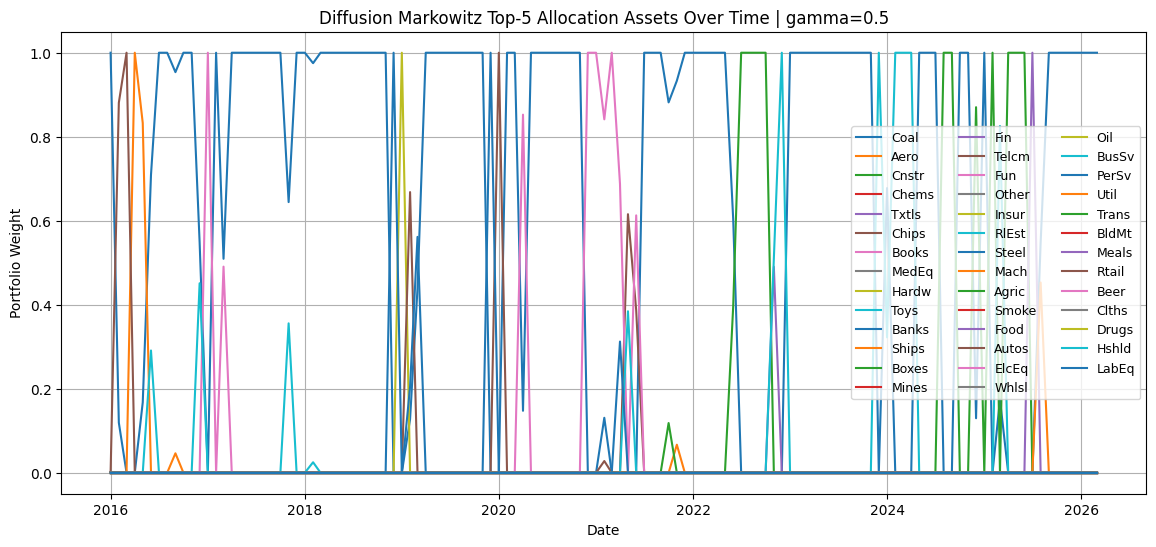

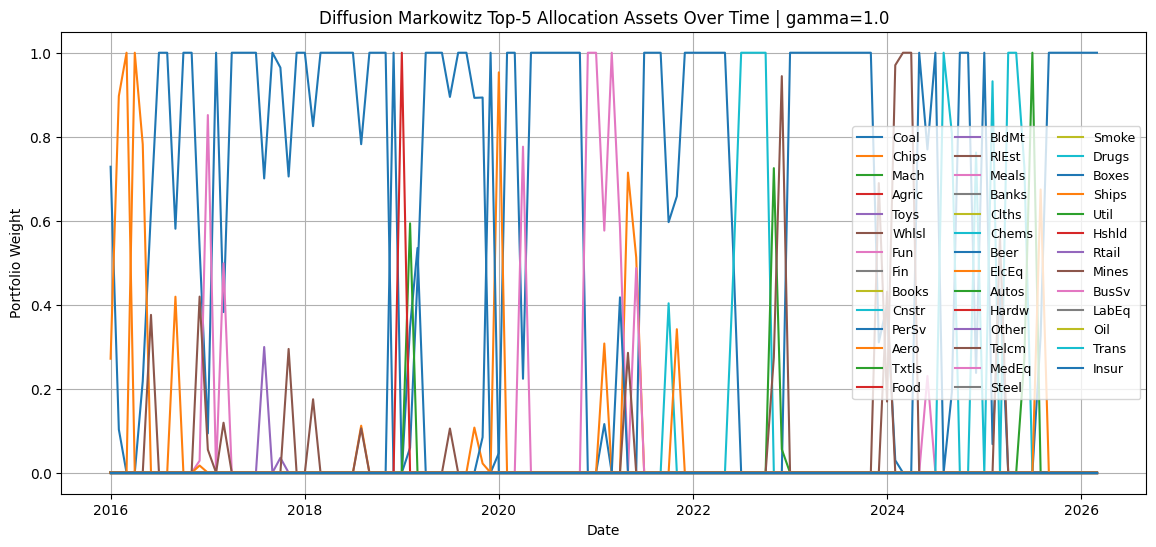

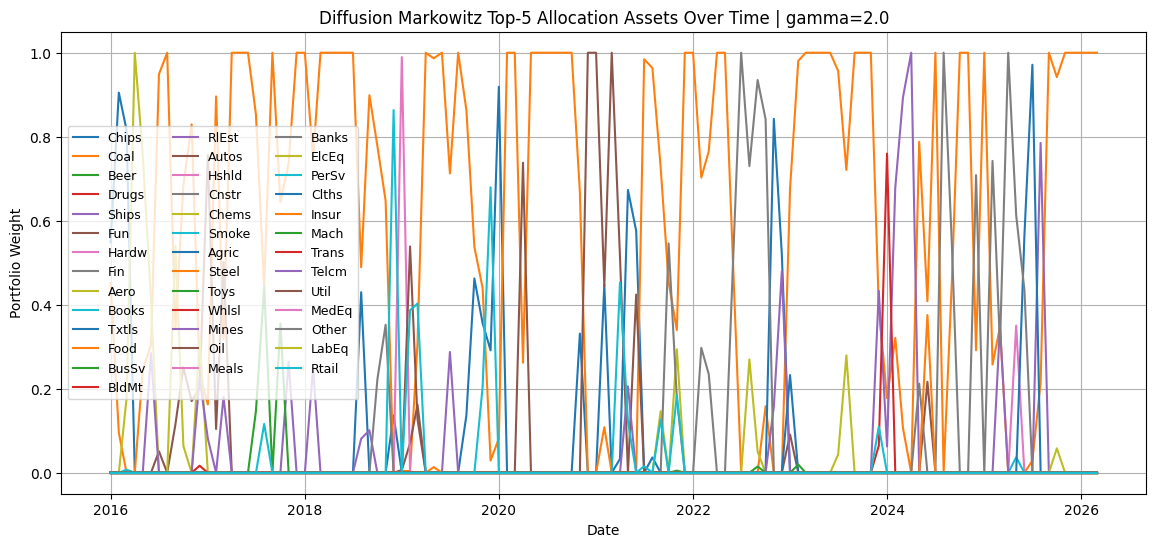

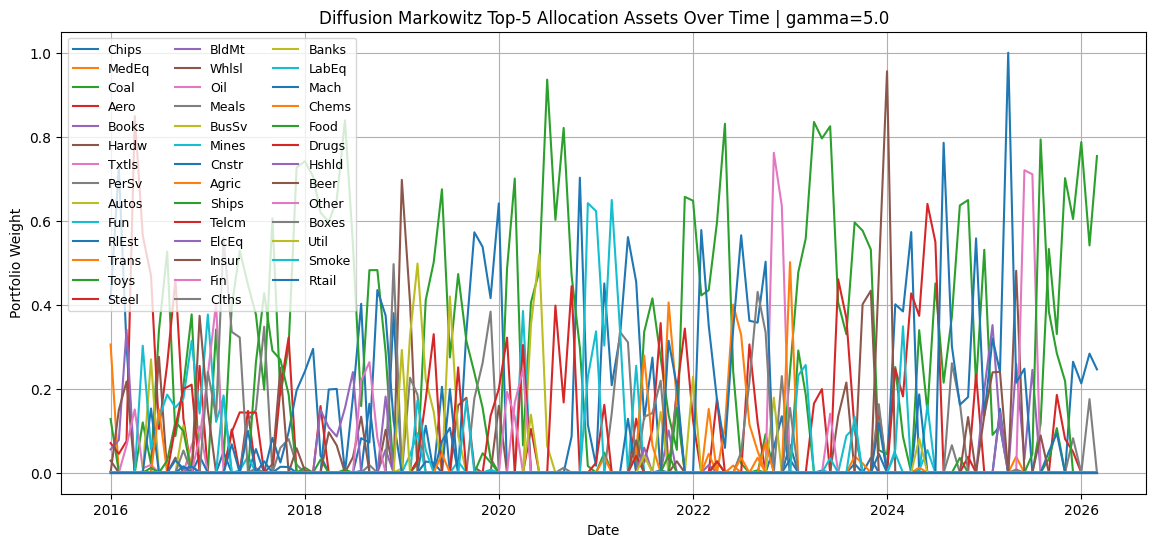

In [28]:
# ============================================================
# Plot top-5 monthly allocation weights
# ============================================================

for gamma in risk_aversions:
    df_g = top5_allocations_df[
        top5_allocations_df["risk_aversion"] == gamma
    ].copy()

    # Assets that ever appear in top 5 for this gamma
    top_assets = df_g["asset"].unique()

    # Build full time-series matrix for those assets
    W = pd.DataFrame(
        ra_weights[gamma],
        index=pd.Index(dates, name="date"),
        columns=asset_names,
    )

    W_top = W[top_assets]

    plt.figure(figsize=(14, 6))

    for asset in top_assets:
        plt.plot(
            W_top.index,
            W_top[asset],
            linewidth=1.5,
            label=asset,
        )

    plt.title(f"Diffusion Markowitz Top-5 Allocation Assets Over Time | gamma={gamma}")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Weight")
    plt.legend(ncol=3, fontsize=9)
    plt.grid(True)
    plt.show()